Resize Validation Notebook

This notebook will:

randomly sample images
resize them
show before/after comparison
help you visually validate preprocessing

Total images found: 47770


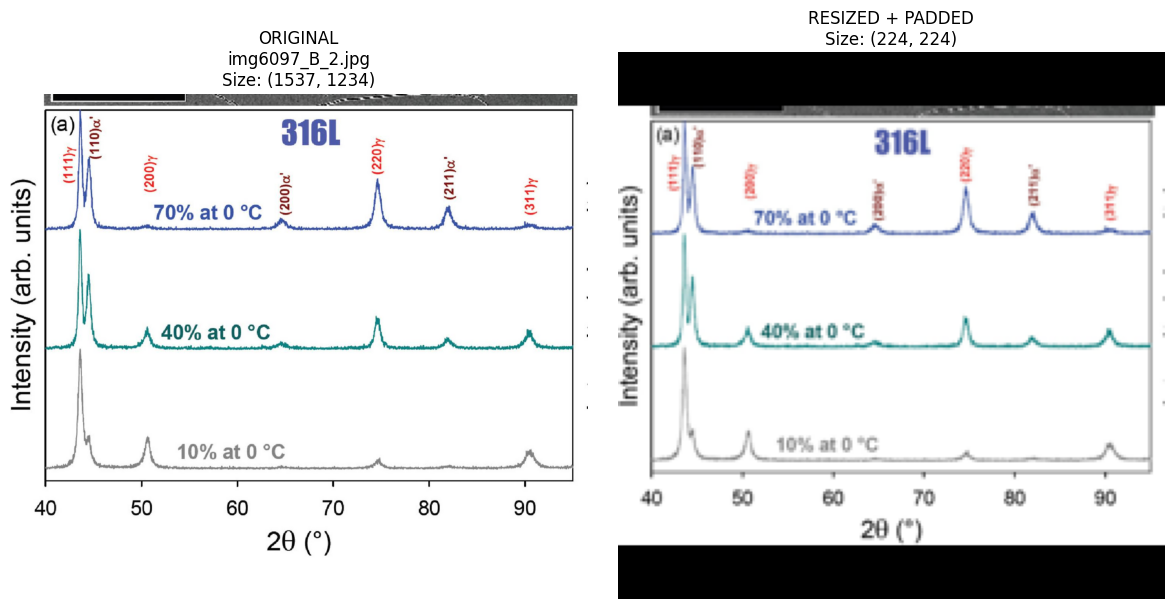

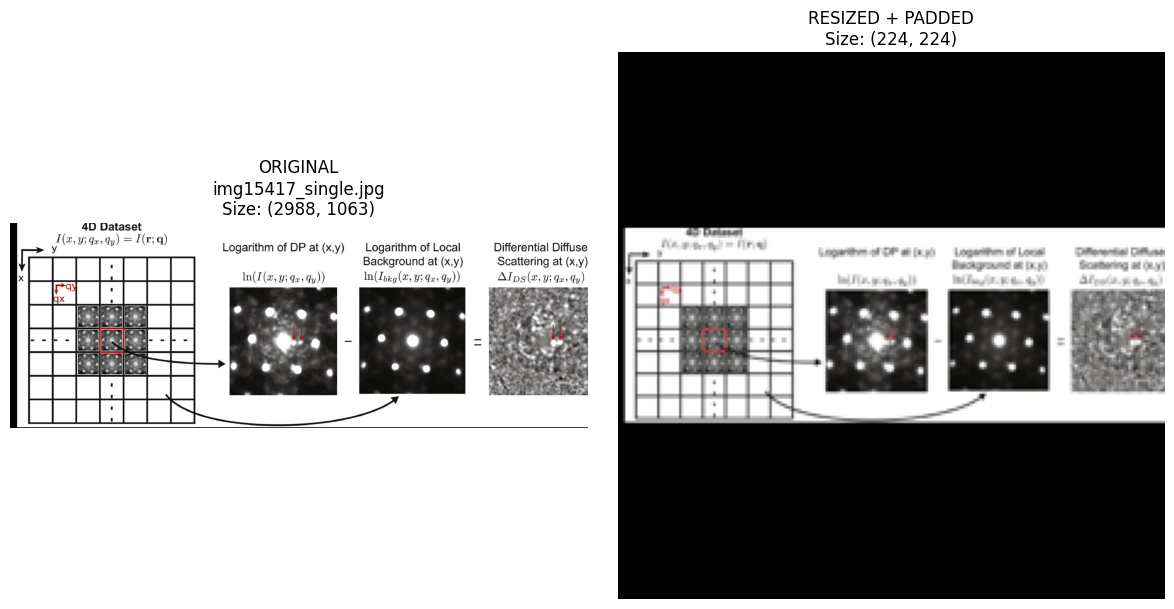

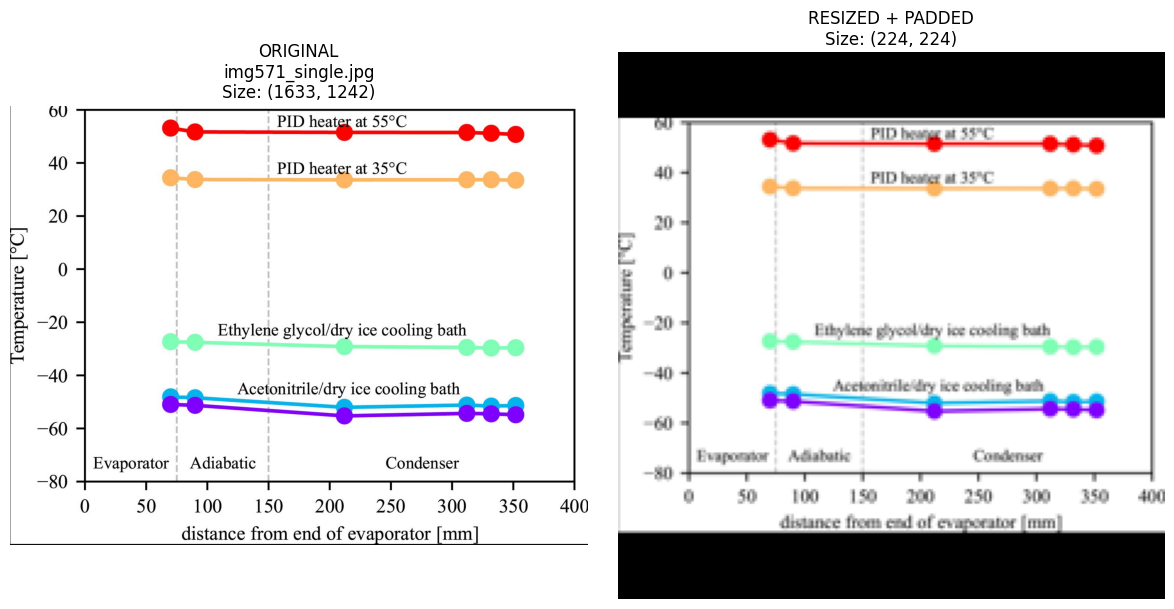

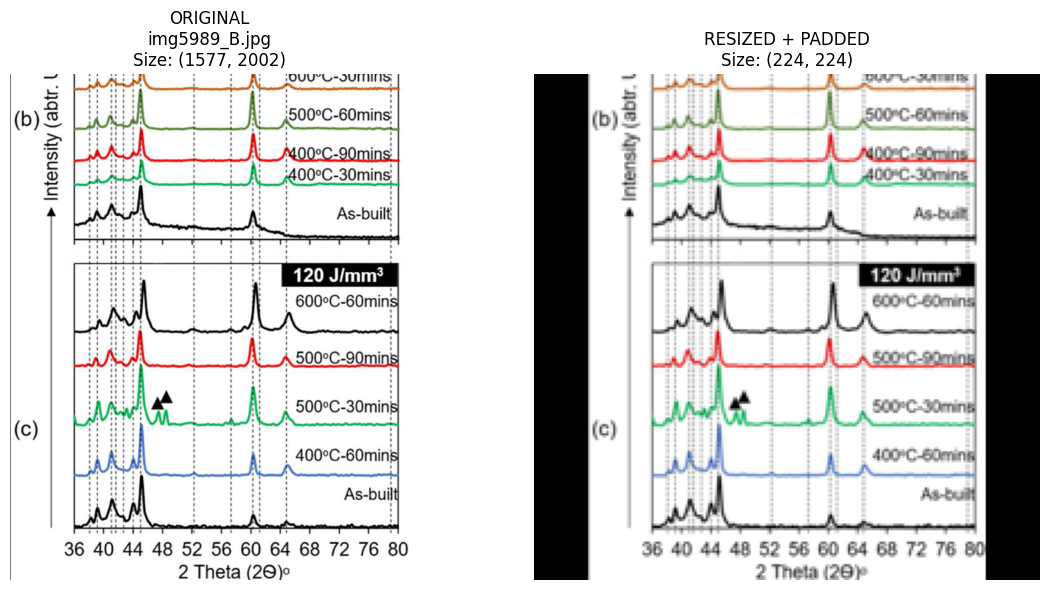

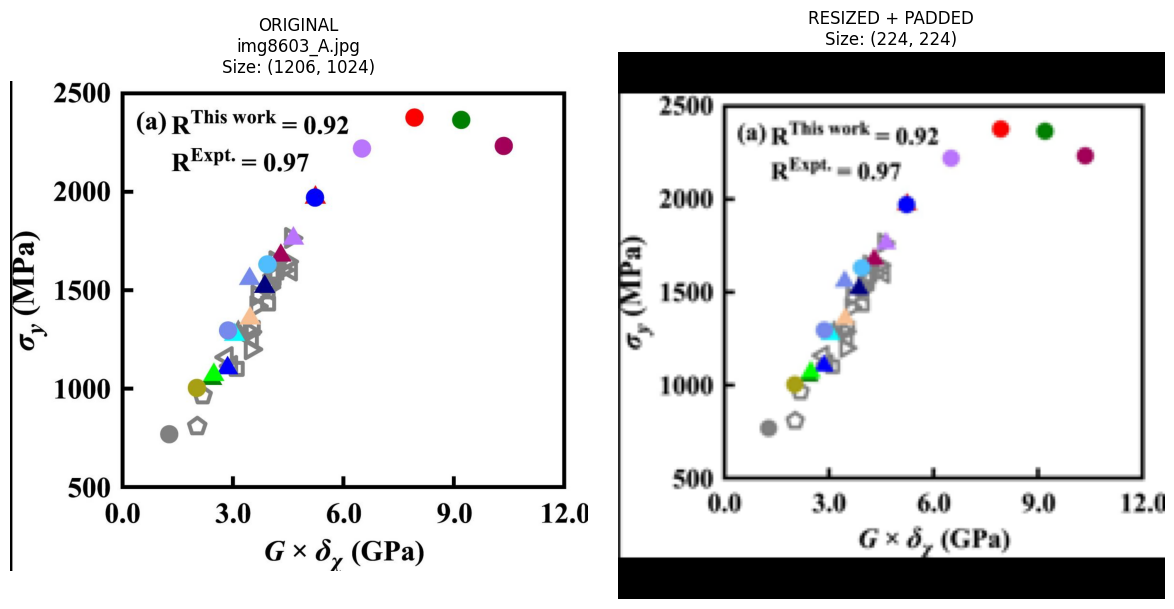

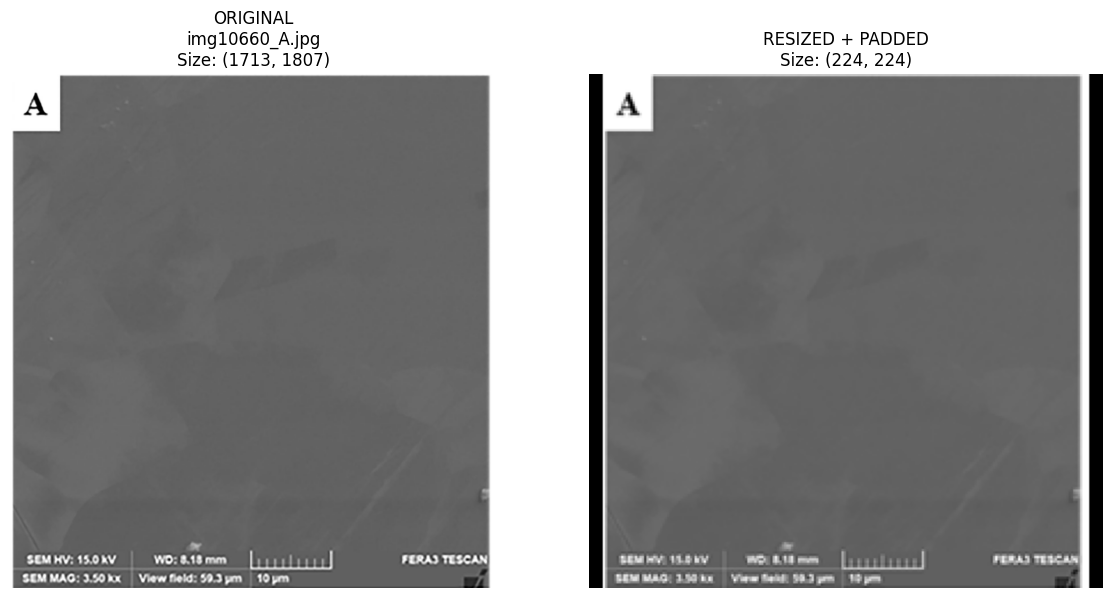

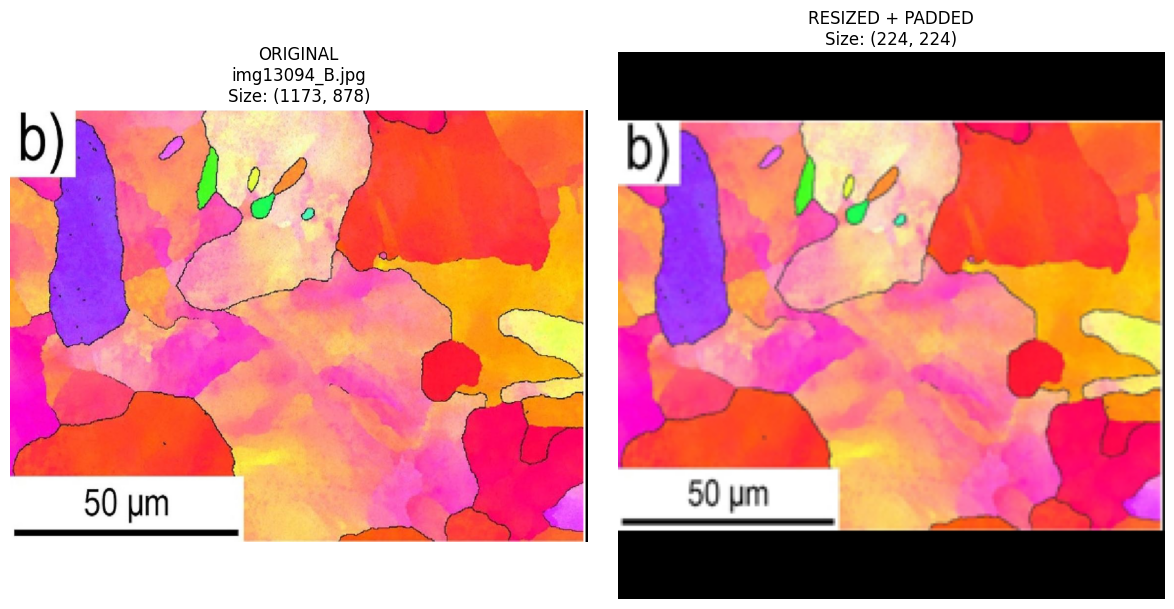

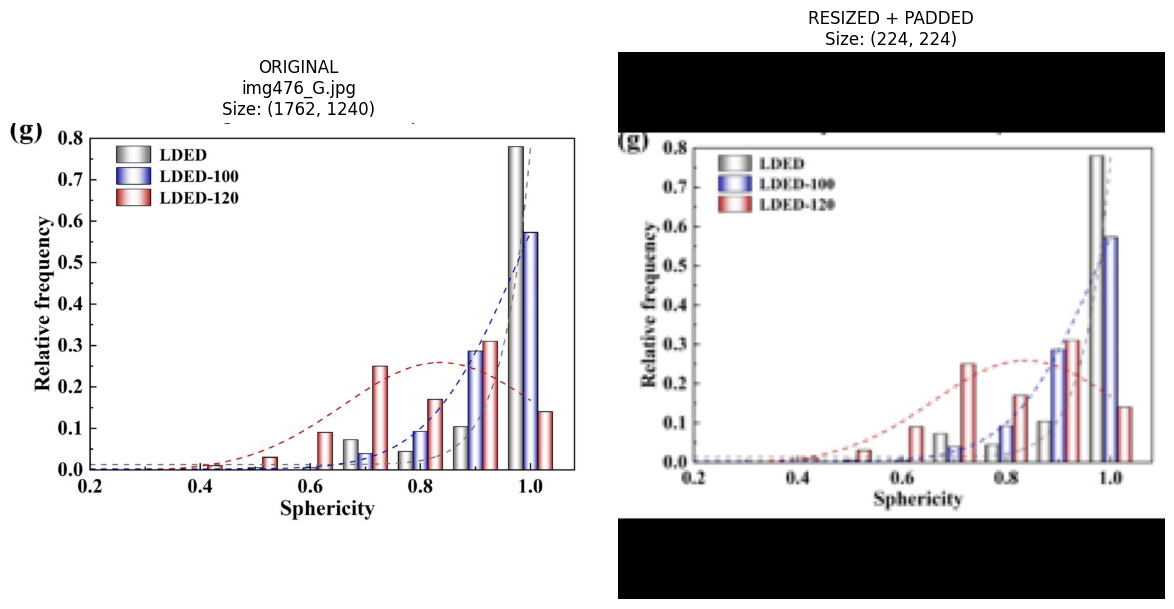

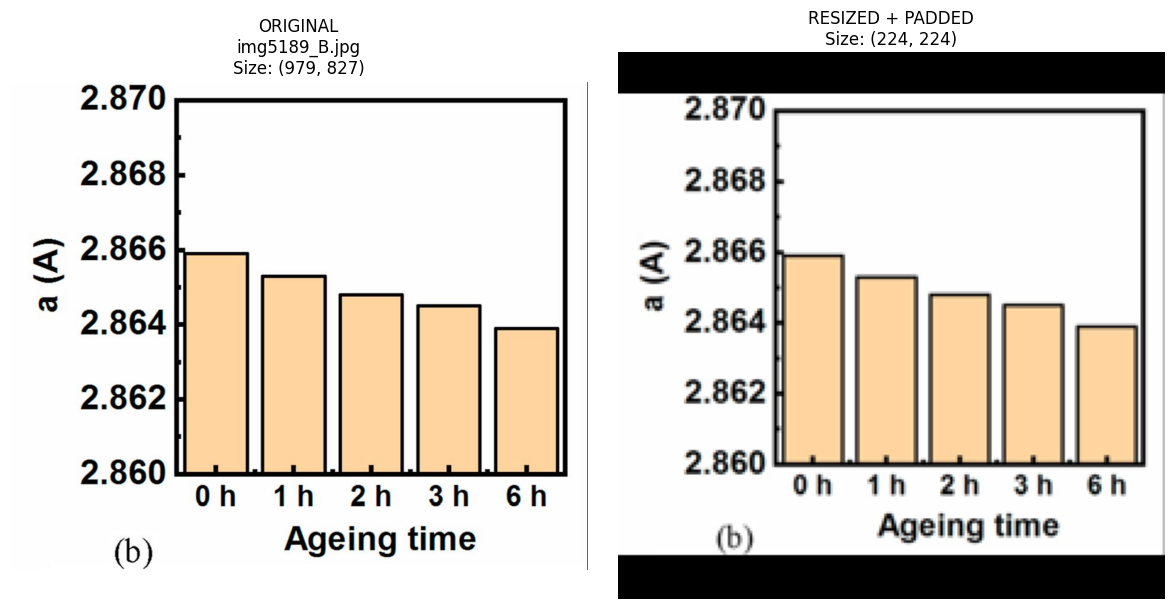

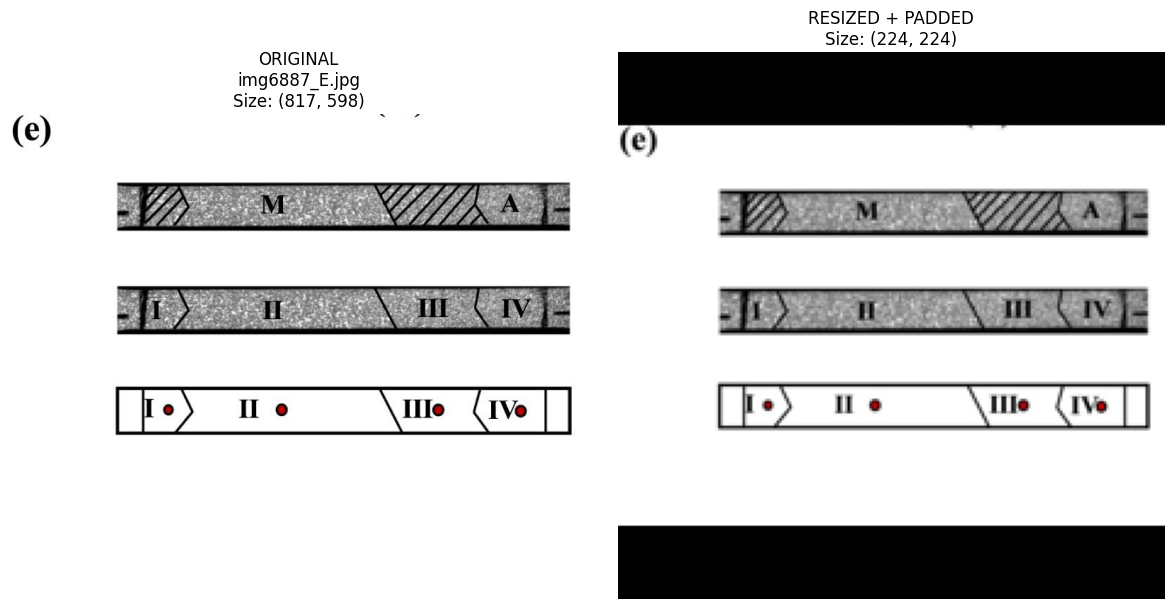

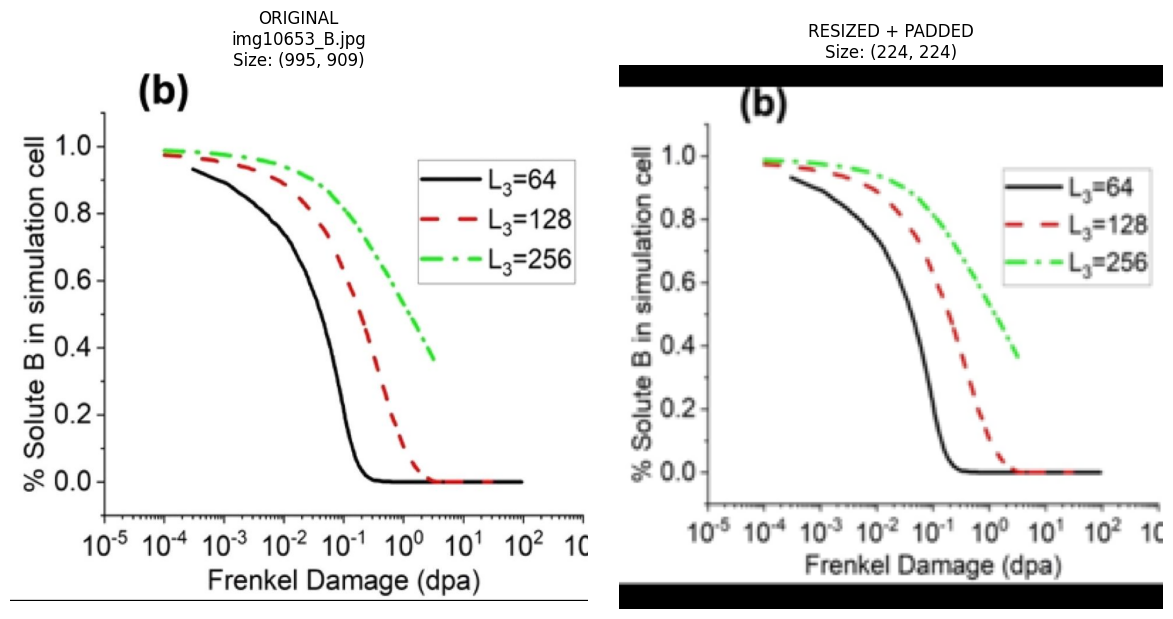

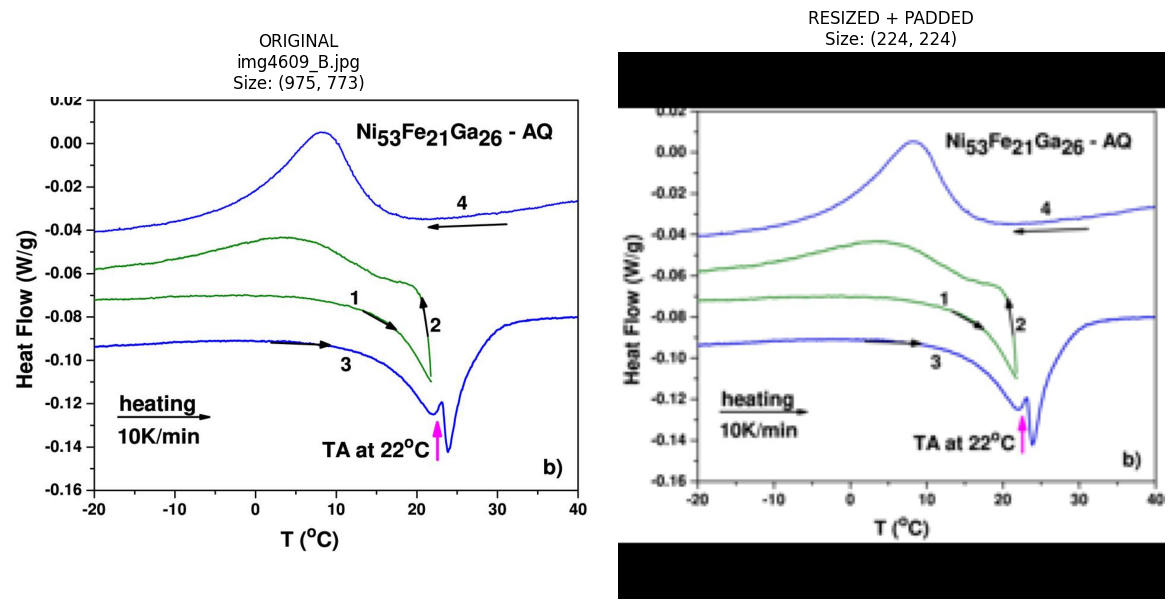

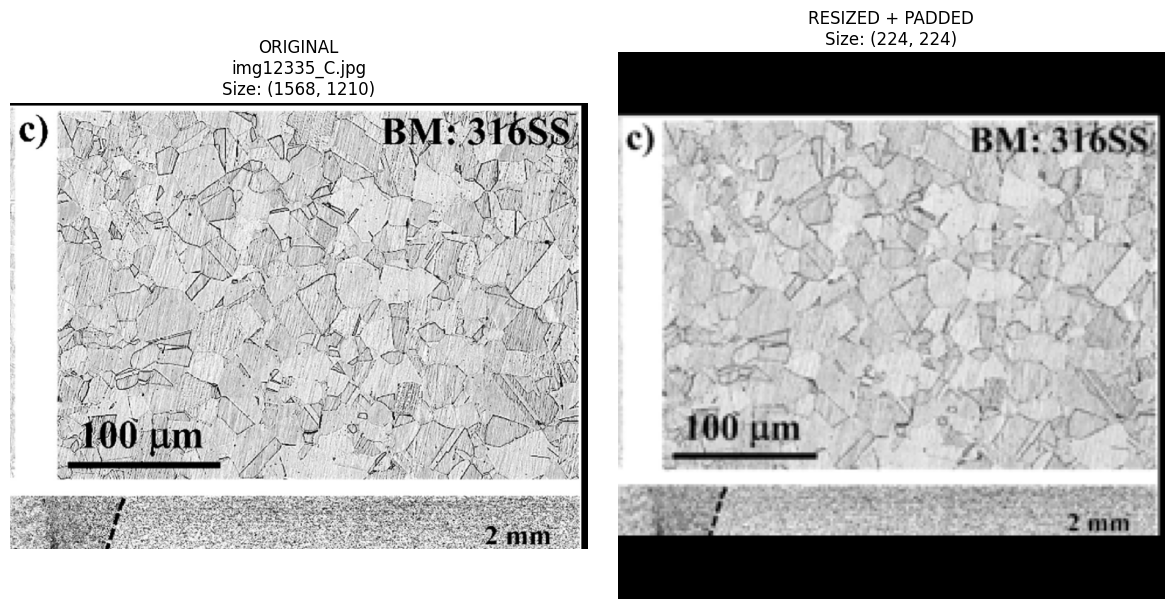

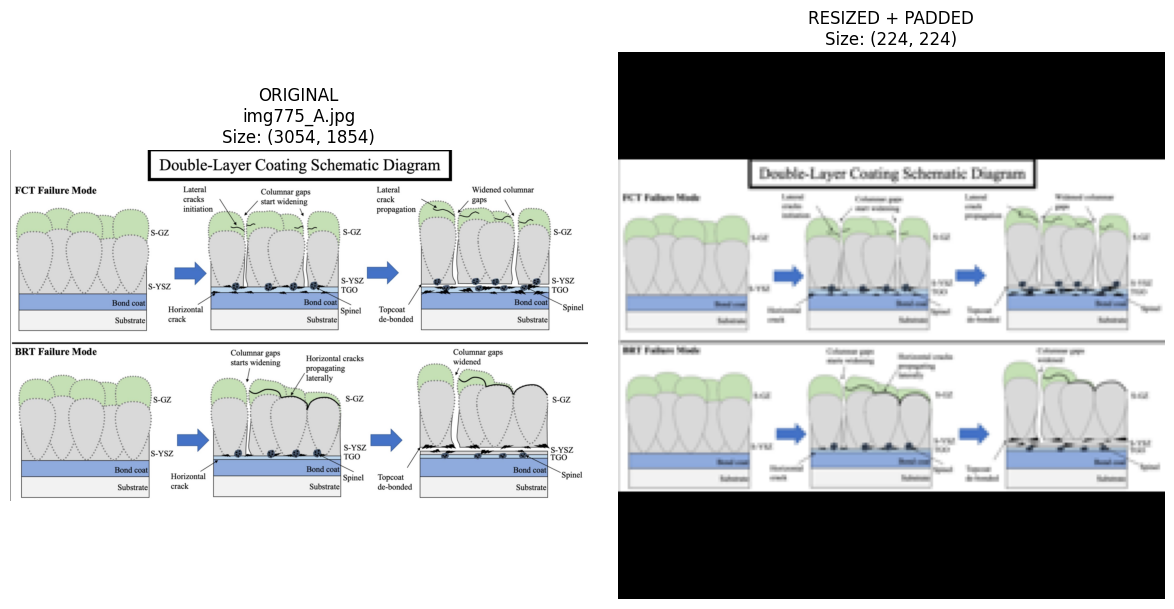

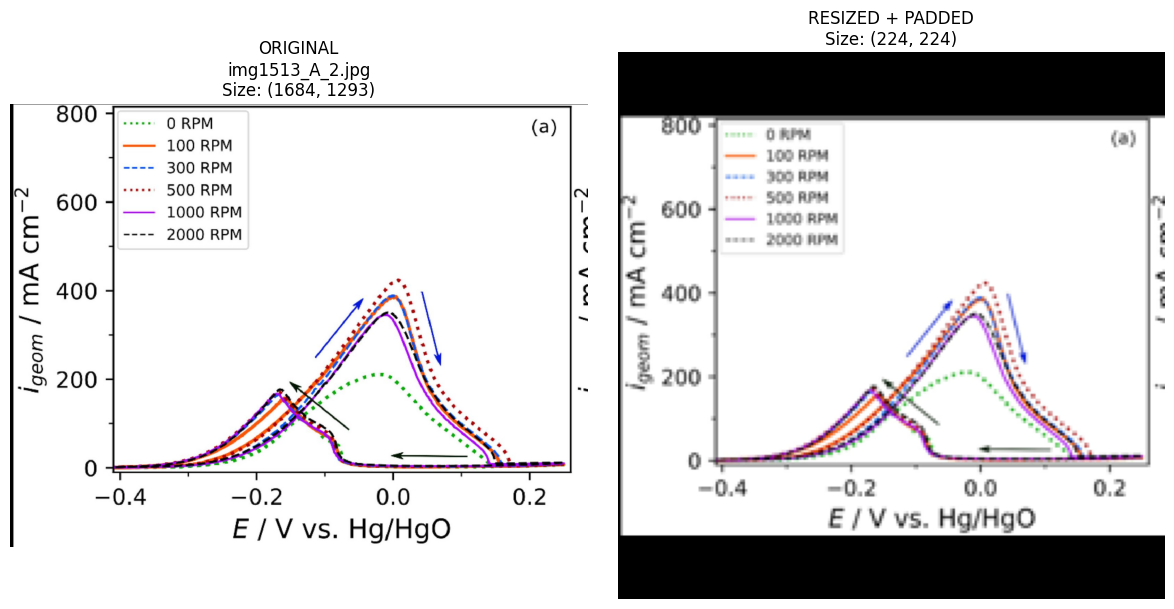

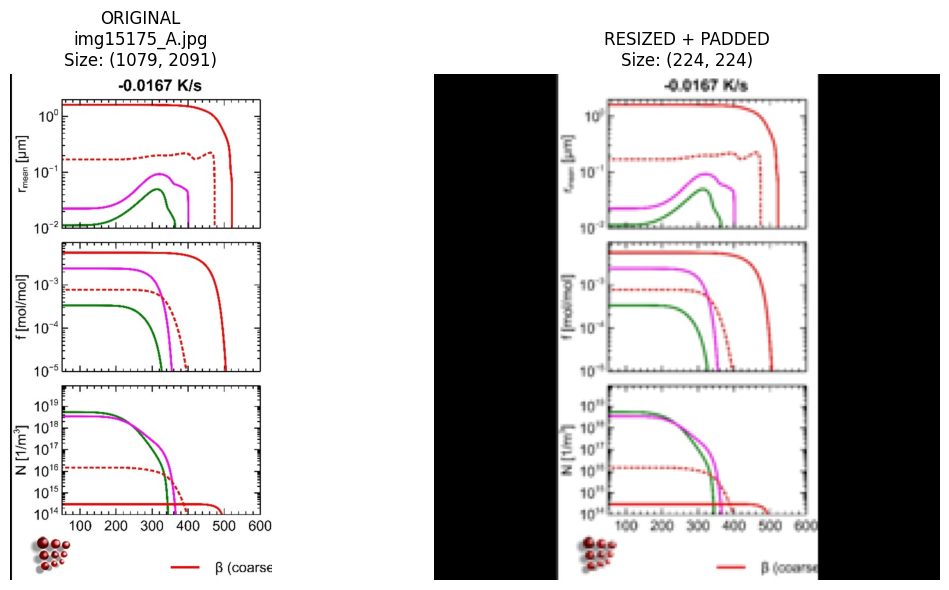

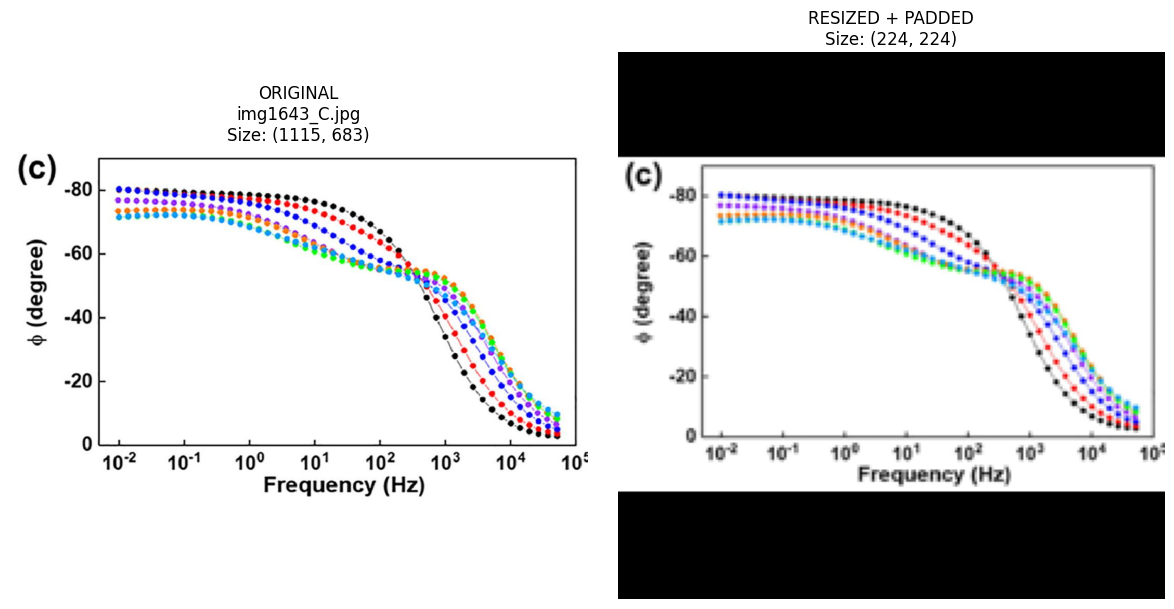

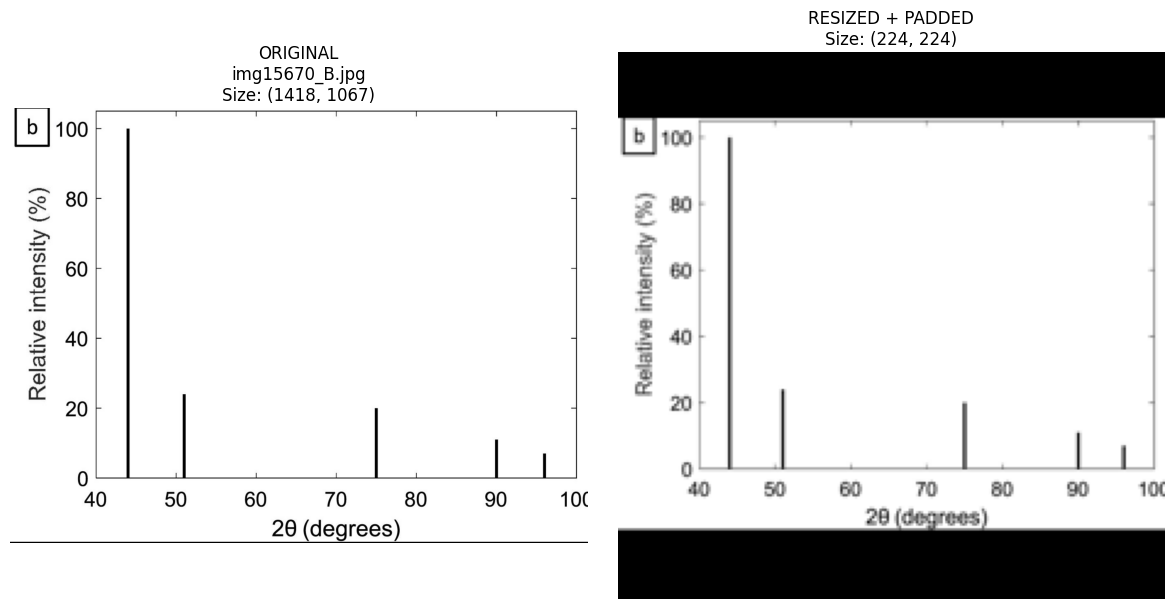

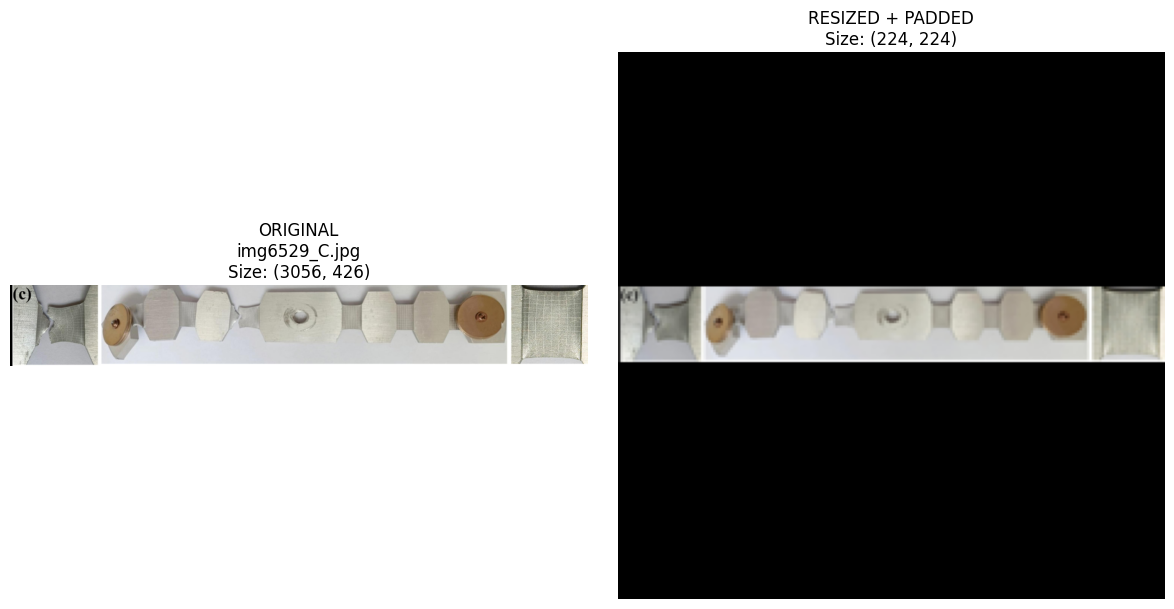

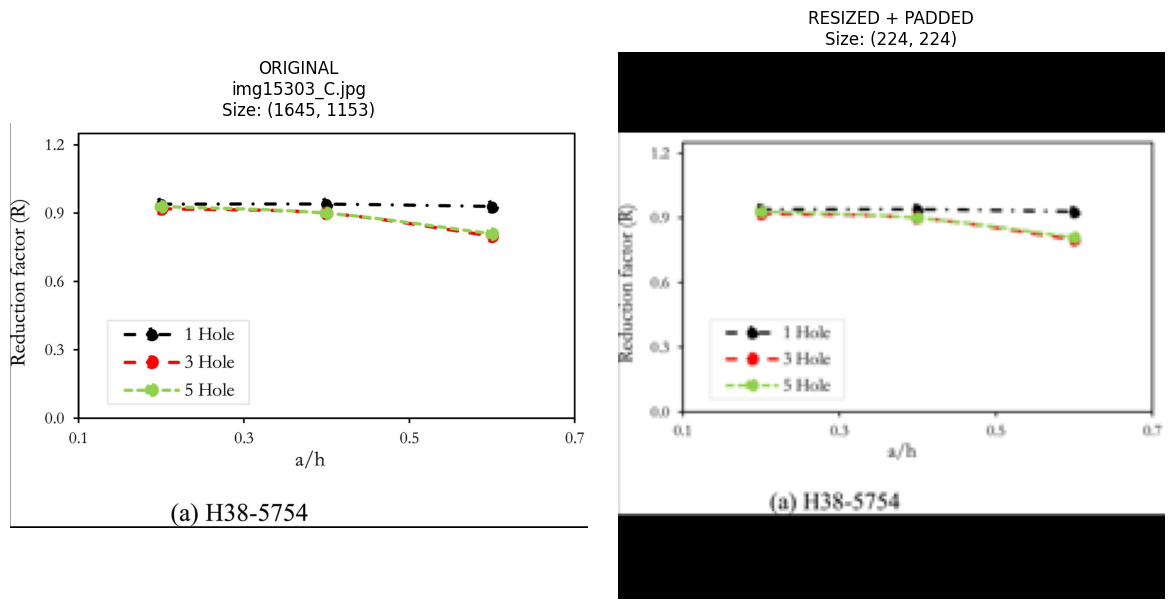

In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

# =========================================================
# CONFIGURATION
# =========================================================

RAW_DIR = Path("../data/raw")

VALID_EXTENSIONS = [
    ".png",
    ".jpg",
    ".jpeg",
    ".tif",
    ".bmp"
]

TARGET_SIZE = (224, 224)

# =========================================================
# RESIZE + PADDING FUNCTION
# =========================================================

def resize_with_padding(
    img,
    target_size=(224,224),
    background_color=(0,0,0)
):

    img = img.copy()

    # preserve aspect ratio
    img.thumbnail(target_size)

    # create padded canvas
    new_img = Image.new(
        "RGB",
        target_size,
        background_color
    )

    # center image
    left = (
        target_size[0] - img.width
    ) // 2

    top = (
        target_size[1] - img.height
    ) // 2

    # paste image
    new_img.paste(img, (left, top))

    return new_img

# =========================================================
# COLLECT IMAGE PATHS
# =========================================================

image_paths = [
    p for p in RAW_DIR.glob("**/*")
    if p.suffix.lower() in VALID_EXTENSIONS
]

print(f"Total images found: {len(image_paths)}")

# =========================================================
# RANDOM SAMPLE
# =========================================================

sample_size = 20

sample_paths = random.sample(
    image_paths,
    sample_size
)

# =========================================================
# VISUAL VALIDATION
# =========================================================

for i, path in enumerate(sample_paths):

    try:

        # open image
        img = Image.open(path).convert("RGB")

        # resize image
        resized = resize_with_padding(
            img,
            target_size=TARGET_SIZE
        )

        # create comparison plot
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(12,6)
        )

        # original
        axes[0].imshow(img)

        axes[0].set_title(
            f"ORIGINAL\n"
            f"{path.name}\n"
            f"Size: {img.size}"
        )

        axes[0].axis("off")

        # resized
        axes[1].imshow(resized)

        axes[1].set_title(
            f"RESIZED + PADDED\n"
            f"Size: {resized.size}"
        )

        axes[1].axis("off")

        plt.tight_layout()

        plt.show()

    except Exception as e:

        print(f"Error with {path}: {e}")